In [ ]:
"""
General Pipeline
1. Choosing universe (filtration)
-->for now placeholder for tickers
2. Finding signals (noise or not)
-->testing correlation, covariance, 
3. Execution ()
-->how to issue orders quickly


Concept Idea: Mid cap stat arb on intrasector securities. or etfs vs underlying net asset value of baske
"""

In [1]:
#Packages
import pandas as pd
import seaborn as sns
import wrds
import matplotlib.pyplot as plt

In [2]:
#Data Pipeline
db=wrds.Connection(wrds_username='bosekaikini')
db.create_pgpass_file()
print(db.list_libraries())
#wrds cloud is another option but we will run it locally for now

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\Bose\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
pgpass file created at C:\Users\Bose\AppData\Roaming\postgresql\pgpass.conf
['aha_sample', 'ahasamp', 'auditsmp', 'auditsmp_all', 'bank', 'bank_all', 'bank_premium_samp', 'banksamp', 'block', 'block_all', 'boardex', 'boardex_na', 'boardex_trial', 'boardsmp', 'bvd_amadeus_trial', 'bvd_bvdbankf_trial', 'bvd_orbis_trial', 'bvdsamp', 'calcbench_trial', 'calcbnch', 'candid_samp', 'cboe', 'cboe_all', 'cboe_sample', 'cboesamp', 'cddsamp', 'ciqsamp', 'ciqsamp_capstrct', 'ciqsamp_common', 'ciqsamp_keydev', 'ciqsamp_pplintel', 'ciqsamp_ratings', 'ciqsamp_transactions', 'ciqsamp_transcripts', 'cisdmsmp', 'columnar', 'comp', 'comp_execucomp', 'comp_global_daily', 'comp_na_daily_all', 'comp_segments_hist_daily', 'compsamp', 'compsamp_

In [8]:
#Data testing
db.describe_table(library='crsp', table='dsi')

sample_query="""
SELECT date,usdval,ewretx
FROM crsp.dsi
WHERE date >= '2020-01-01'
"""

df=db.raw_sql(sample_query)
print(df)

Approximately 26051 rows in crsp.dsi.
            date         usdval    ewretx
0     2020-01-02  41156335900.0  0.005428
1     2020-01-03  41464750500.0 -0.003072
2     2020-01-06  41211825700.0  0.004519
3     2020-01-07  41345979800.0 -0.000057
4     2020-01-08  41255458200.0  0.000903
...          ...            ...       ...
1253  2024-12-24  74889584800.0   0.01025
1254  2024-12-26  75679041300.0  0.012038
1255  2024-12-27  75702330000.0 -0.004754
1256  2024-12-30  74890031400.0 -0.001173
1257  2024-12-31  74153696300.0 -0.000491

[1258 rows x 3 columns]


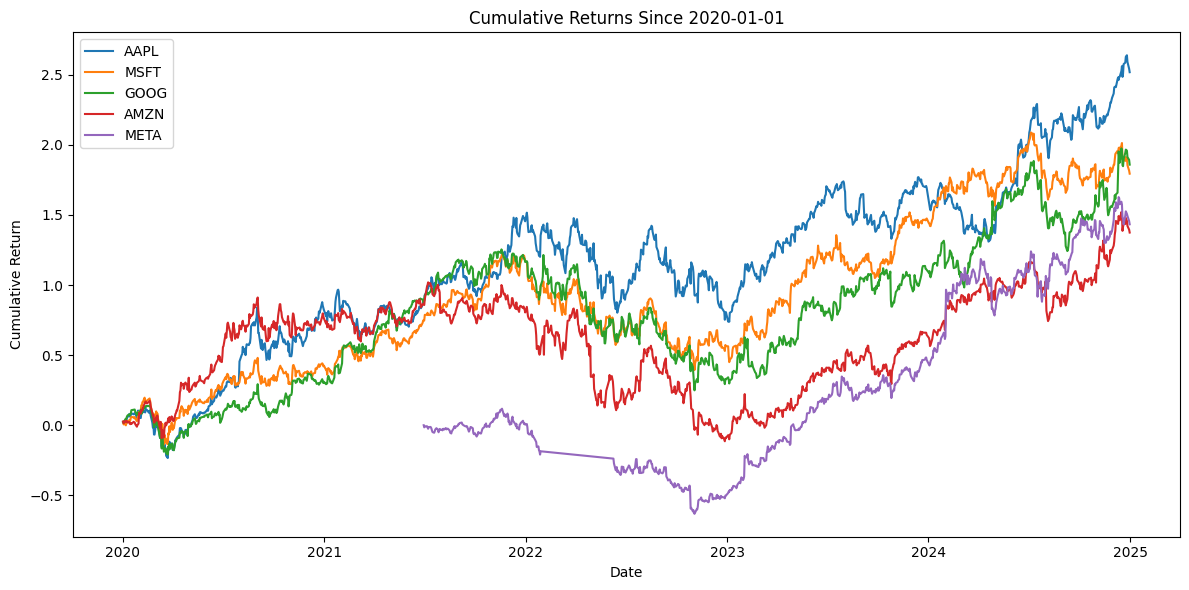

In [ ]:
symbols = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META']
price_query = """
SELECT a.date, b.ticker, a.ret
FROM crsp.dsf AS a
JOIN crsp.stocknames AS b
  ON a.permno = b.permno
 AND a.date BETWEEN b.namedt AND b.nameenddt
WHERE a.date >= '2020-01-01'
  AND b.ticker IN ('AAPL', 'MSFT', 'GOOG', 'AMZN', 'META')
"""

# Pull the ticker-level data into a dedicated dataframe.
df_prices = db.raw_sql(price_query, date_cols=['date'])
df_prices = df_prices.sort_values(['ticker', 'date'])

plt.figure(figsize=(12, 6))
for symbol in symbols:
    s = df_prices[df_prices['ticker'] == symbol].copy()
    # Convert simple returns to cumulative growth of $1 for a clean comparison plot.
    s['cum_return'] = (1 + s['ret'].fillna(0)).cumprod() - 1
    plt.plot(s['date'], s['cum_return'], label=symbol)

plt.title('Cumulative Returns since 2020-01-01')
plt.xlabel('Date')
plt.ylabel('Cumulative Return of $1')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Correlation across tickers, using a wide returns table.
returns_wide = df_prices.pivot(index='date', columns='ticker', values='ret')
corr_matrix = returns_wide.corr()
print(corr_matrix)

#p=0.7 threshold
filtered_matrix=corr_matrix[corr_matrix.abs() > 0.7]
print(filtered_matrix)

#assume i have the 2 correlated assets
pair=('AAPL', 'MSFT')
pair_gap=df_prices[df_prices['ticker'] == pair[0]].set_index('date')['ret'] - df_prices[df_prices['ticker'] == pair[1]].set_index('date')['ret']
if pair_gap.mean() > 0:
    print(f"Short {pair[0]} and Long {pair[1]}")

ticker      AAPL      AMZN      GOOG      META      MSFT
ticker                                                  
AAPL    1.000000  0.592574  0.648089  0.471636  0.748504
AMZN    0.592574  1.000000  0.651410  0.598603  0.678745
GOOG    0.648089  0.651410  1.000000  0.577578  0.743747
META    0.471636  0.598603  0.577578  1.000000  0.585676
MSFT    0.748504  0.678745  0.743747  0.585676  1.000000
ticker      AAPL  AMZN      GOOG  META      MSFT
ticker                                          
AAPL    1.000000   NaN       NaN   NaN  0.748504
AMZN         NaN   1.0       NaN   NaN       NaN
GOOG         NaN   NaN  1.000000   NaN  0.743747
META         NaN   NaN       NaN   1.0       NaN
MSFT    0.748504   NaN  0.743747   NaN  1.000000
